# Week 11: DBSCAN and Hierarchical Clustering

## Marketing Performance Profiling and Model Feasibility

**Research question:** How do customer-engagement attributes form interpretable profiles, and what do density-based and hierarchical clustering reveal about the strength and stability of those profiles in this synthetic marketing dataset?

This notebook applies DBSCAN, core/border/noise points, hierarchical agglomerative clustering (HAC), linkage methods, and dendrograms. Results are exploratory, not causal or predictive claims.


## Design

Record identifiers are excluded because they cannot define reusable profiles. Revenue is not used to fit clusters and is shown only as a descriptive comparison afterward. The profile space uses **Subscription_Length** and **Customer_Satisfaction_Post_Refund**: direct engagement measures that can be examined transparently in two dimensions. Both are standardized before distance-based analysis.


In [ ]:
# Standard-library configuration
import warnings

# Data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Density-based and hierarchical clustering tools
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
RANDOM_STATE = 42

DATA_PATH = 'marketing_and_product_performance.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head())


Dataset shape: 10,000 rows × 17 columns


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


### Data context

The file contains **10,000 records and 17 columns**, matching the dataset documentation. The notebook loads the data directly and defines `RANDOM_STATE = 42`, so sampled figures and all subsequent results are reproducible.


In [2]:
# Audit completeness and document feature selection.
audit = pd.DataFrame(
    {
        'data_type': df.dtypes.astype(str),
        'missing_values': df.isna().sum(),
        'unique_values': df.nunique(),
    }
)
display(audit)

identifier_columns = [
    'Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID'
]
profile_features = [
    'Subscription_Length', 'Customer_Satisfaction_Post_Refund'
]

print('Profile features used for fitting:')
print(profile_features)
print()
print('Excluded identifiers:')
print(identifier_columns)


,data_type,missing_values,unique_values
Campaign_ID,str,0,10000
Product_ID,str,0,10000
Budget,float64,0,9995
Clicks,int64,0,4298
Conversions,int64,0,999
Revenue_Generated,float64,0,9997
ROI,float64,0,451
Customer_ID,str,0,10000
Subscription_Tier,str,0,3
Subscription_Length,int64,0,35


Profile features used for fitting:
['Subscription_Length', 'Customer_Satisfaction_Post_Refund']

Excluded identifiers:
['Campaign_ID', 'Product_ID', 'Customer_ID', 'Flash_Sale_ID', 'Bundle_ID']


### EDA finding: data quality and scope

There are **no missing values** in the selected file. The audit also shows that the five ID fields have 10,000 unique values, so retaining them would make a distance-based model compare record labels rather than reusable behavior. The two selected profile variables have only 35 and 4 distinct values, respectively. That limited cardinality is important when interpreting apparent clusters later.


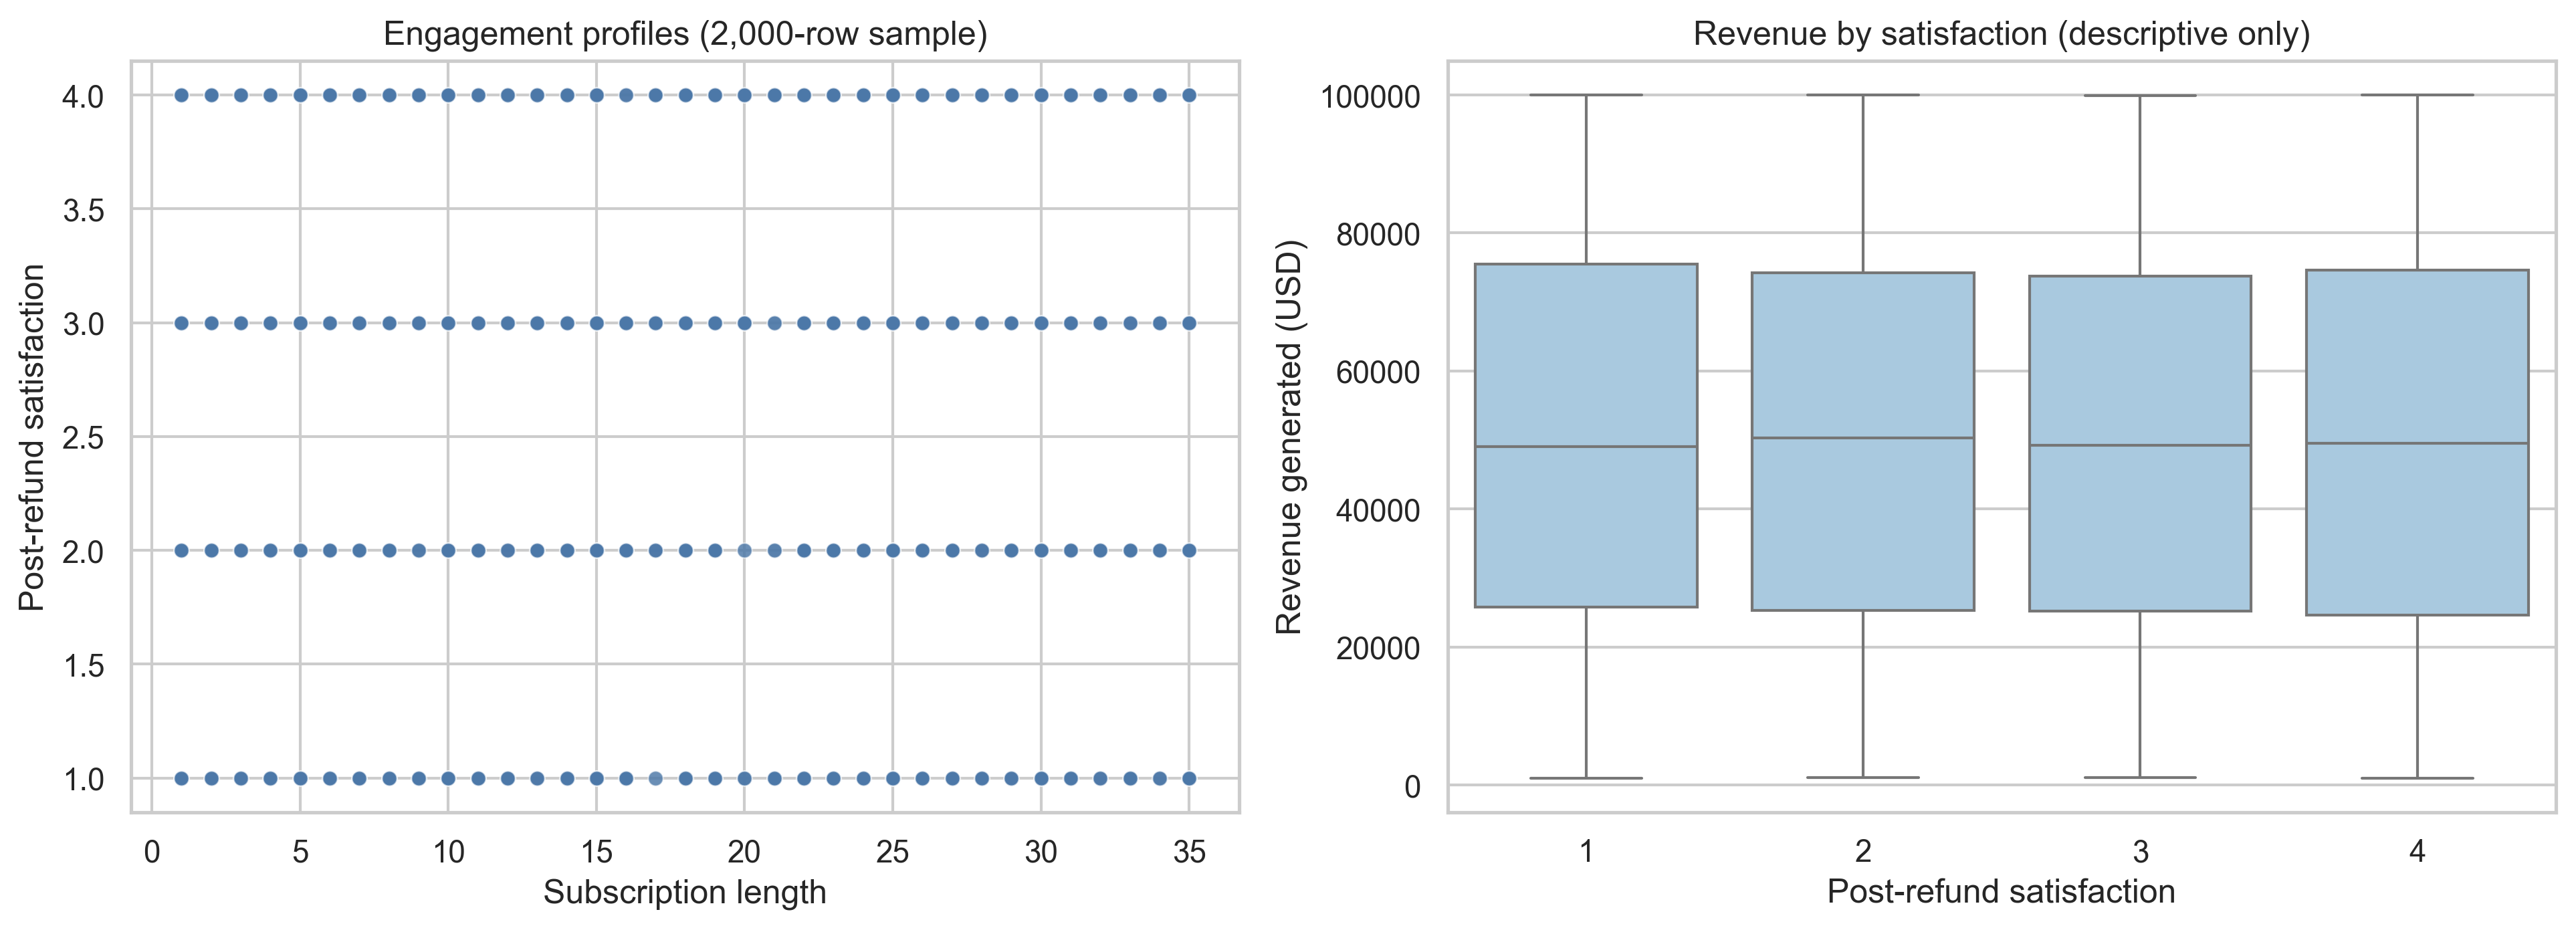

,count,mean,std,min,25%,50%,75%,max
Subscription_Length,10000.000,-0.000,1.000,-1.677,-0.888,-0.002,0.885,1.673
Customer_Satisfaction_Post_Refund,10000.000,-0.000,1.000,-1.348,-0.450,-0.450,0.448,1.347


In [3]:
# Inspect raw profiles; revenue is descriptive and not used for clustering.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
plot_sample = df.sample(n=2_000, random_state=RANDOM_STATE)

sns.scatterplot(
    data=plot_sample,
    x='Subscription_Length',
    y='Customer_Satisfaction_Post_Refund',
    alpha=0.35,
    s=28,
    color='#4C78A8',
    ax=axes[0],
)
axes[0].set_title('Engagement profiles (2,000-row sample)')
axes[0].set_xlabel('Subscription length')
axes[0].set_ylabel('Post-refund satisfaction')

sns.boxplot(
    data=df,
    x='Customer_Satisfaction_Post_Refund',
    y='Revenue_Generated',
    color='#A0CBE8',
    ax=axes[1],
)
axes[1].set_title('Revenue by satisfaction (descriptive only)')
axes[1].set_xlabel('Post-refund satisfaction')
axes[1].set_ylabel('Revenue generated (USD)')
plt.tight_layout()
plt.show()

# Standardization prevents one variable's units from dominating distance.
X_profile = StandardScaler().fit_transform(df[profile_features])
scaled_profile = pd.DataFrame(X_profile, columns=profile_features)
display(scaled_profile.describe().T.style.format('{:.3f}'))


### EDA finding: visible structure is not automatically a customer segment

The scatterplot shows horizontal bands because satisfaction has only four possible ratings. The revenue boxplots are included for business context, but they are descriptive only: revenue was deliberately withheld from clustering. This distinction prevents the analysis from implying that the discovered profiles explain or predict revenue.


## DBSCAN: epsilon, MinPts, and point roles

DBSCAN finds connected dense regions without a preselected cluster count. Epsilon is the neighborhood radius; min_samples is MinPts, the number of observations (including the point itself) needed to be a core point. A k-nearest-neighbor diagnostic and sensitivity analysis make parameter selection transparent.


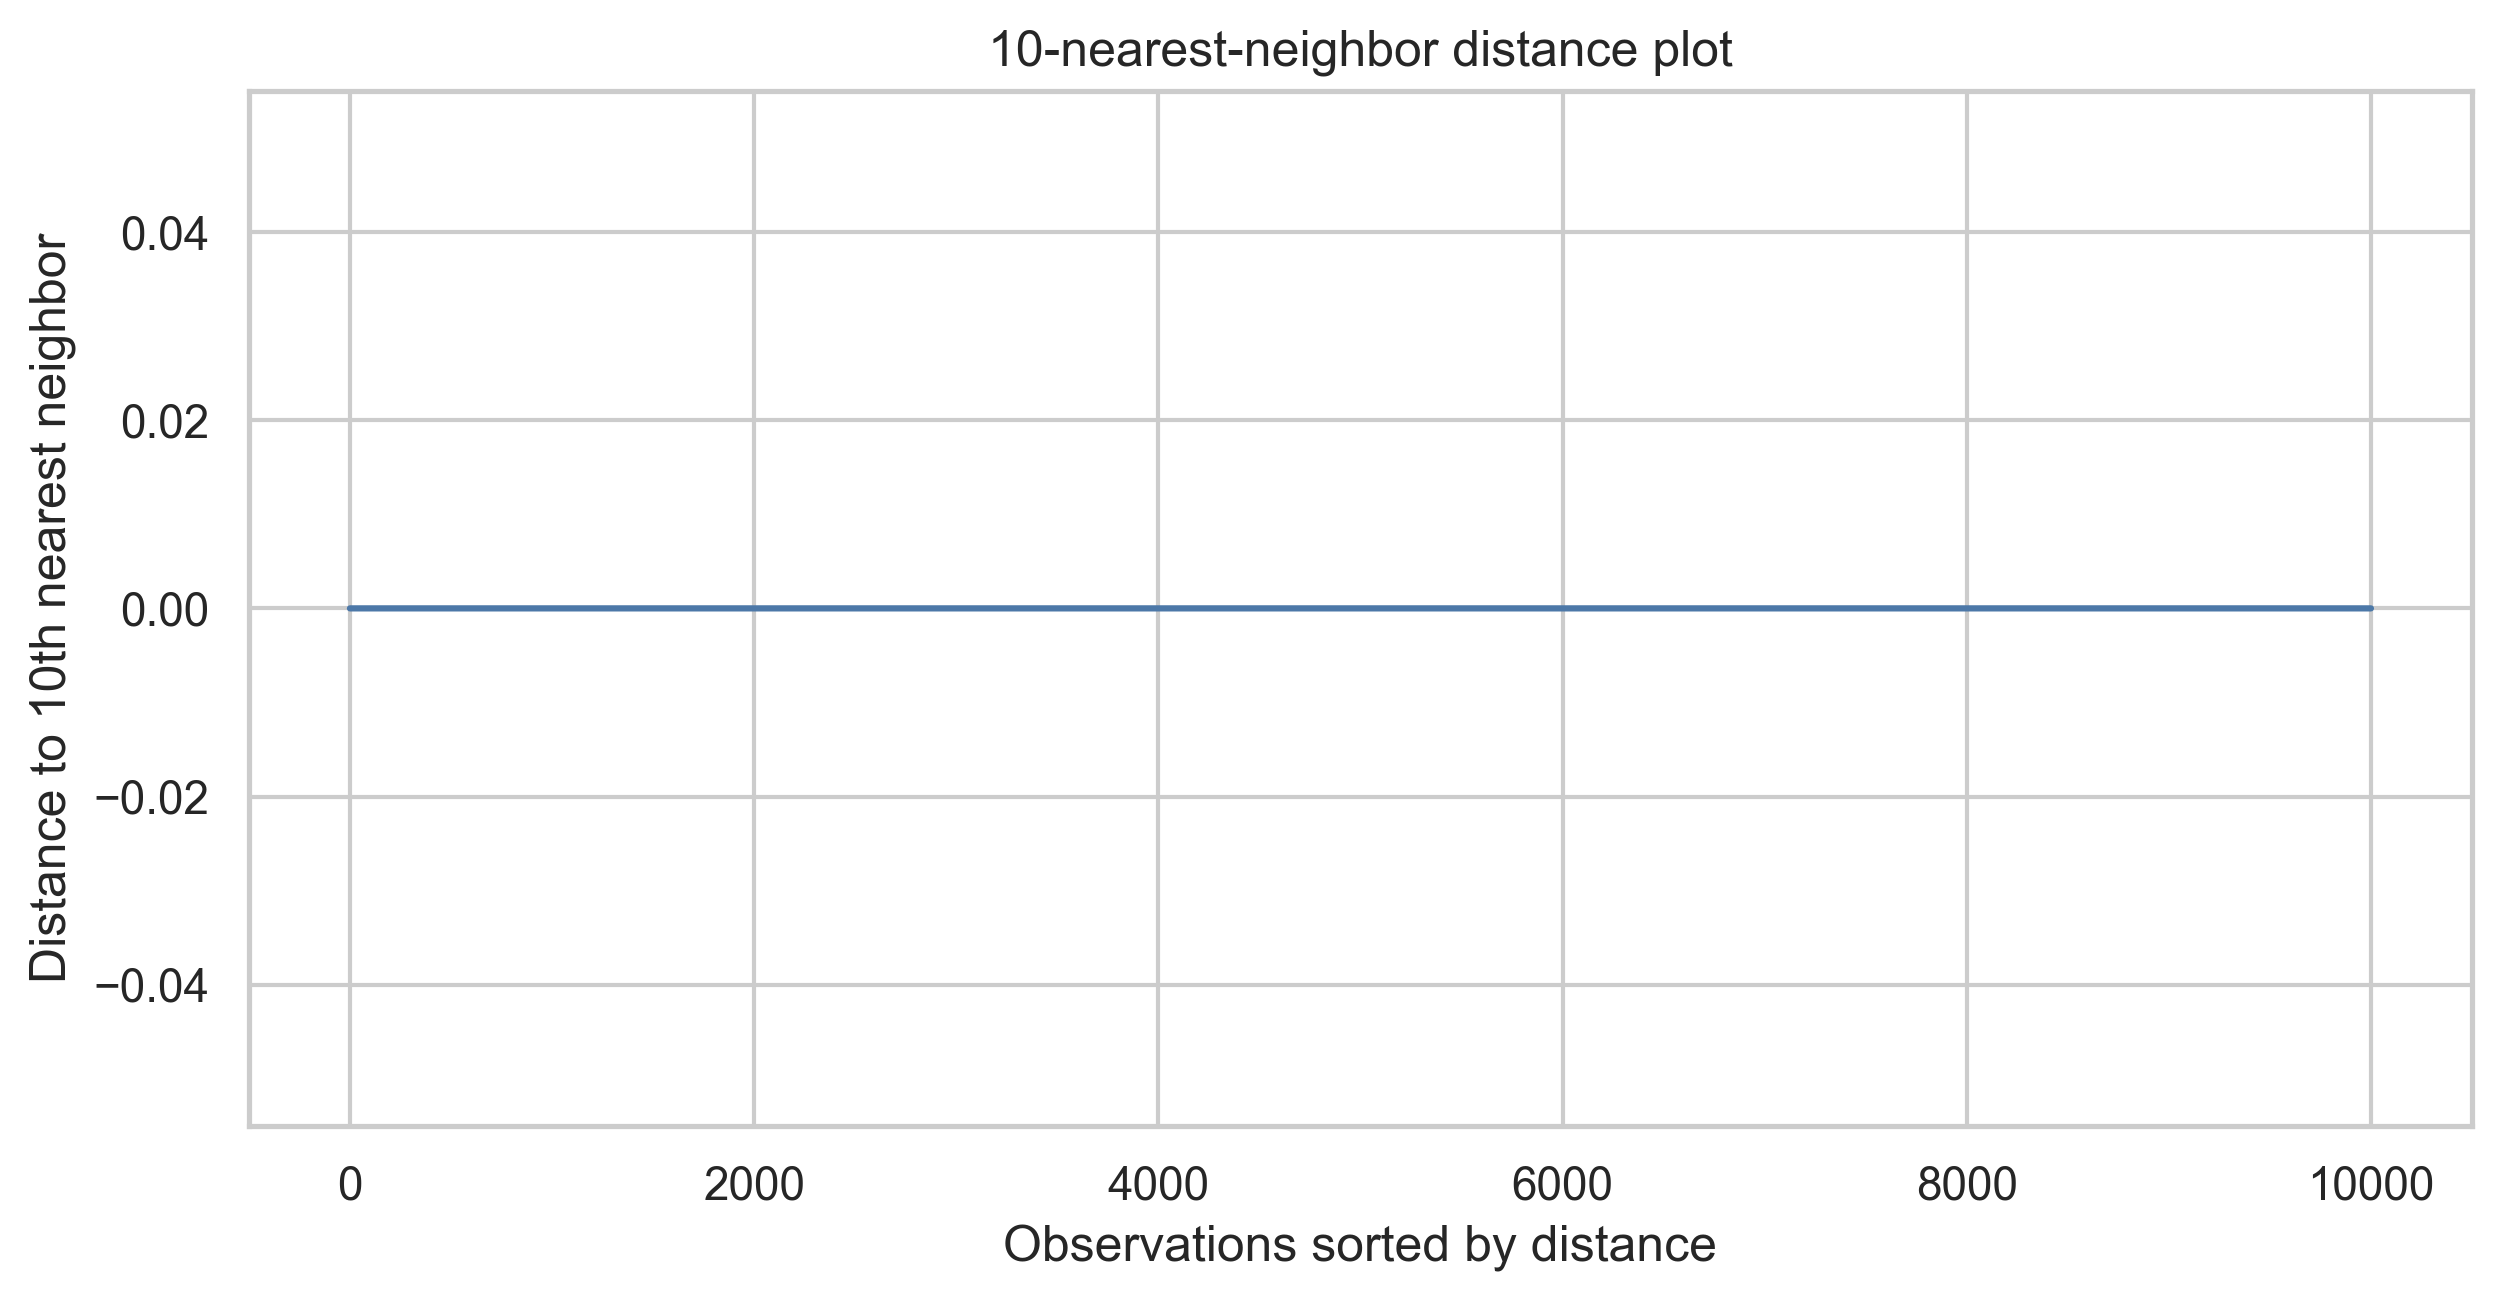

,eps,min_samples,clusters,noise_share,silhouette_excluding_noise
0,0.05,5,140,0.0%,1.000
1,0.10,5,4,0.0%,0.263
2,0.15,5,4,0.0%,0.263
3,0.20,5,4,0.0%,0.263
4,0.30,5,4,0.0%,0.263
5,0.05,10,140,0.0%,1.000
6,0.10,10,4,0.0%,0.263
7,0.15,10,4,0.0%,0.263
8,0.20,10,4,0.0%,0.263
9,0.30,10,4,0.0%,0.263


In [4]:
# Inspect distances to each observation's 10th nearest neighbor.
MIN_SAMPLES = 10
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_profile)
distances, _ = neighbors.kneighbors(X_profile)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8.5, 4.5))
plt.plot(k_distances, color='#4C78A8', linewidth=1.5)
plt.title(f'{MIN_SAMPLES}-nearest-neighbor distance plot')
plt.xlabel('Observations sorted by distance')
plt.ylabel(f'Distance to {MIN_SAMPLES}th nearest neighbor')
plt.tight_layout()
plt.show()

# Compare epsilon and MinPts settings; silhouette excludes DBSCAN noise label -1.
rows = []
for min_samples in [5, 10, 20]:
    for eps in [0.05, 0.10, 0.15, 0.20, 0.30]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_profile)
        non_noise = labels != -1
        clusters = len(set(labels[non_noise]))
        score = np.nan
        if clusters >= 2 and non_noise.sum() > clusters:
            score = silhouette_score(X_profile[non_noise], labels[non_noise])
        rows.append(
            {
                'eps': eps,
                'min_samples': min_samples,
                'clusters': clusters,
                'noise_share': 1 - non_noise.mean(),
                'silhouette_excluding_noise': score,
            }
        )

dbscan_grid = pd.DataFrame(rows)
display(
    dbscan_grid.style.format(
        {
            'eps': '{:.2f}',
            'noise_share': '{:.1%}',
            'silhouette_excluding_noise': '{:.3f}',
        }
    )
)


### DBSCAN diagnostic and parameter sensitivity

The k-distance plot provides an empirical scale for ε rather than choosing it arbitrarily. The sensitivity table is especially revealing here: at ε = 0.05, many tiny groups can obtain an artificially high silhouette; at ε ≥ 0.10, DBSCAN consistently produces four connected groups and no noise. This is not evidence that four natural customer segments exist—it reflects the four-level satisfaction scale and the connected subscription-length values. The selected ε = 0.10 is therefore used as an interpretable demonstration of DBSCAN behavior, not as a claim of optimal segmentation.


,observations,share
Point_Type,,
Core,10000,100.0%
Border,0,0.0%
Noise,0,0.0%


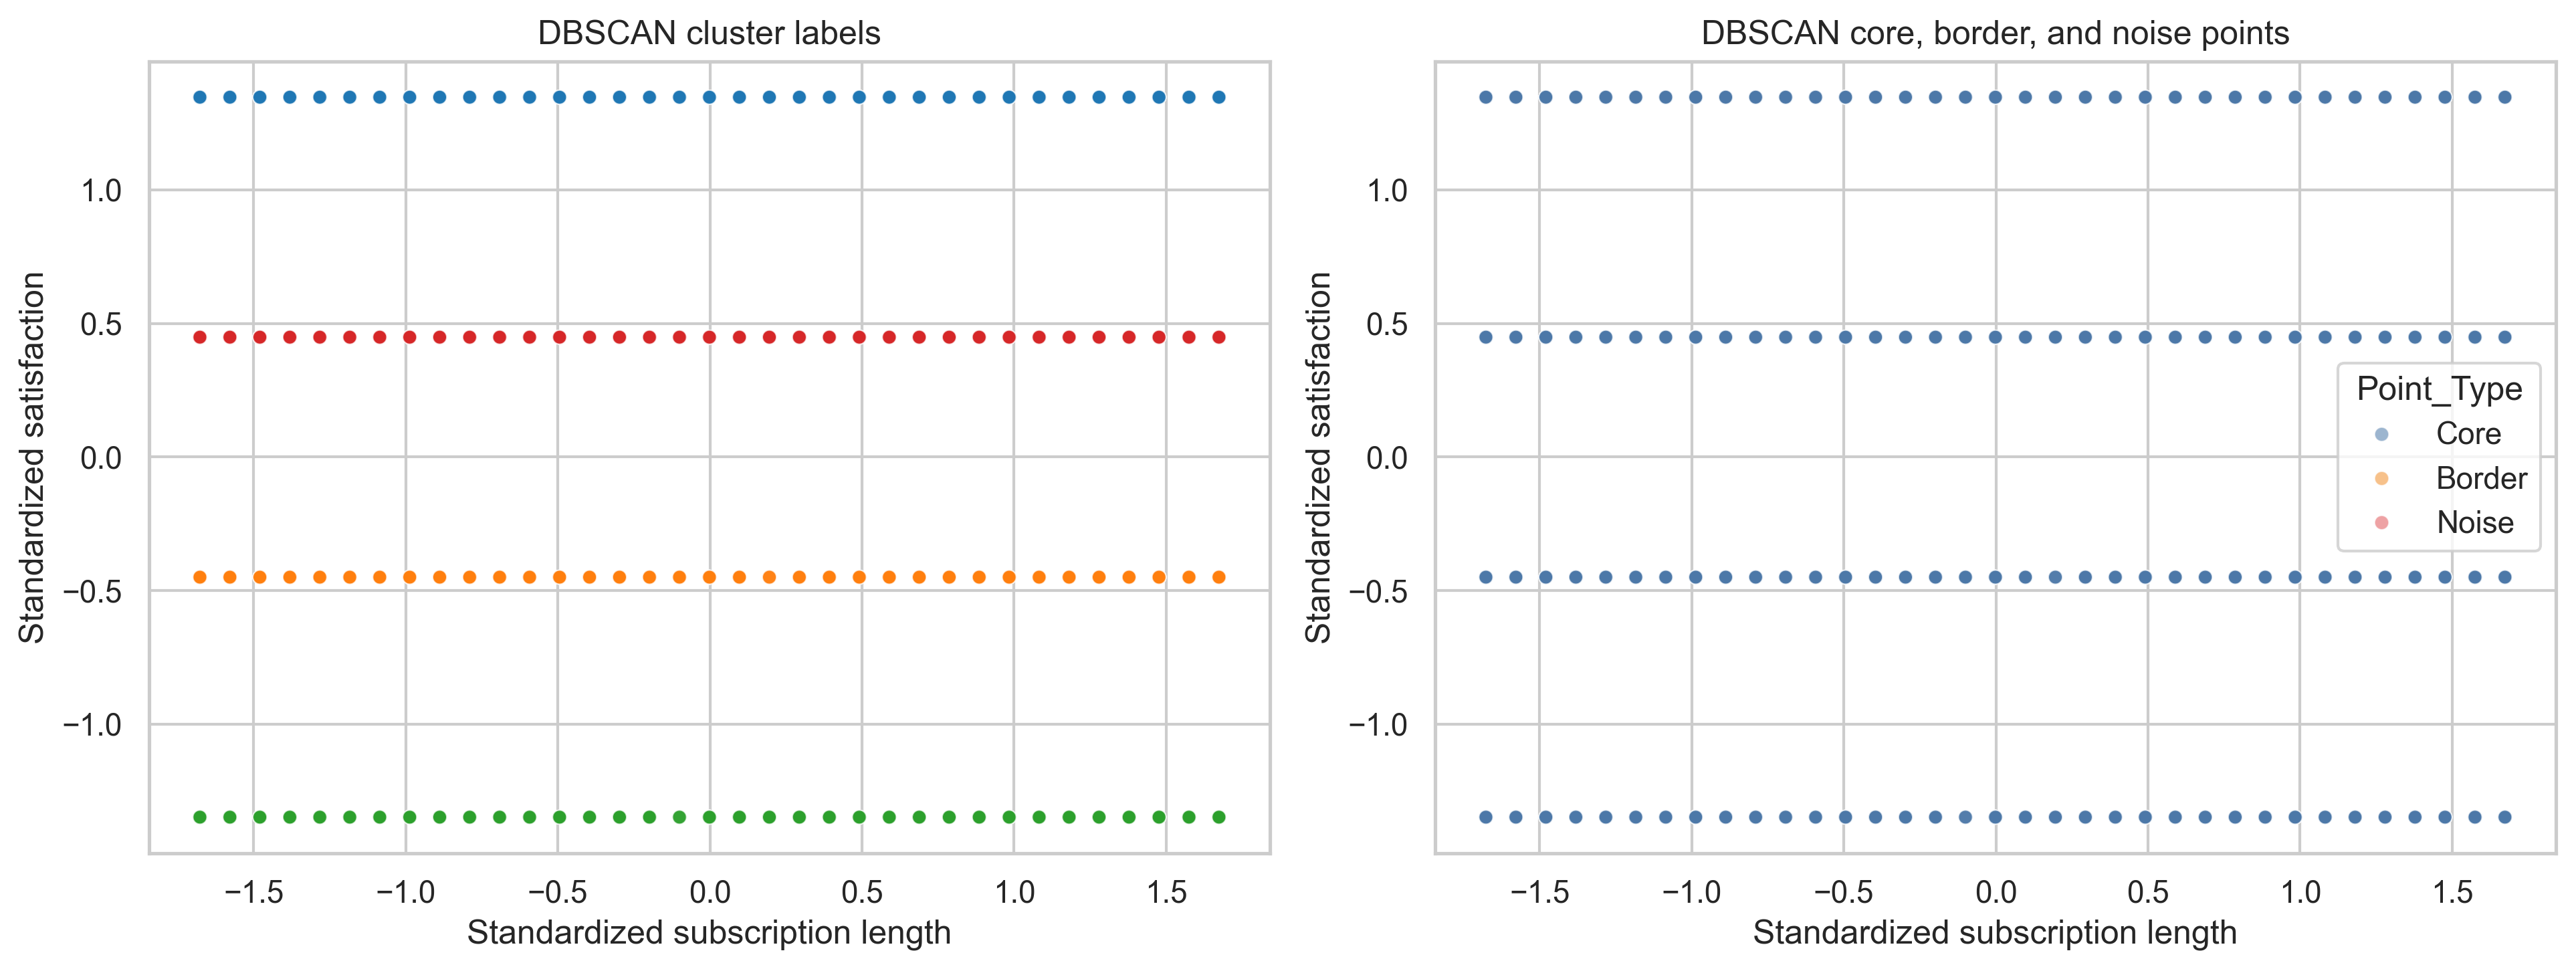

In [5]:
# Fit one selected setting and identify core, border, and noise points.
SELECTED_EPS = 0.10
dbscan = DBSCAN(eps=SELECTED_EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_profile)

core_mask = np.zeros(len(df), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
point_type = np.where(
    dbscan_labels == -1,
    'Noise',
    np.where(core_mask, 'Core', 'Border'),
)

dbscan_results = df[profile_features + ['Revenue_Generated']].copy()
dbscan_results['DBSCAN_Cluster'] = dbscan_labels
dbscan_results['Point_Type'] = point_type

point_summary = (
    dbscan_results['Point_Type']
    .value_counts()
    .reindex(['Core', 'Border', 'Noise'], fill_value=0)
    .to_frame('observations')
)
point_summary['share'] = point_summary['observations'] / len(df)
display(point_summary.style.format({'share': '{:.1%}'}))

plot_data = dbscan_results.sample(n=2_000, random_state=RANDOM_STATE).copy()
plot_data['Length_z'] = scaled_profile.loc[plot_data.index, 'Subscription_Length']
plot_data['Satisfaction_z'] = scaled_profile.loc[
    plot_data.index,
    'Customer_Satisfaction_Post_Refund',
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(
    data=plot_data, x='Length_z', y='Satisfaction_z', hue='DBSCAN_Cluster',
    palette='tab10', alpha=0.55, s=25, legend=False, ax=axes[0],
)
axes[0].set_title('DBSCAN cluster labels')
sns.scatterplot(
    data=plot_data, x='Length_z', y='Satisfaction_z', hue='Point_Type',
    hue_order=['Core', 'Border', 'Noise'],
    palette={'Core': '#4C78A8', 'Border': '#F28E2B', 'Noise': '#E15759'},
    alpha=0.55, s=25, ax=axes[1],
)
axes[1].set_title('DBSCAN core, border, and noise points')
for axis in axes:
    axis.set_xlabel('Standardized subscription length')
    axis.set_ylabel('Standardized satisfaction')
plt.tight_layout()
plt.show()


### DBSCAN result: core, border, and noise points

With ε = 0.10 and MinPts = 10, all observations are assigned to clusters and are classified as **core points**; there are no border or noise observations. This is an unexpected but informative result: the selected feature space is densely connected, so DBSCAN has no isolated records to flag. The four DBSCAN labels largely reproduce satisfaction bands rather than identifying rare behavioral patterns. This is why a DBSCAN result must be interpreted alongside the EDA and parameter sensitivity table.


## Hierarchical agglomerative clustering

HAC begins with one record per cluster and merges groups sequentially. Single linkage uses nearest points and can chain records; complete linkage uses farthest points and favors compact groups; average linkage uses mean pairwise distance; and Ward linkage minimizes increased within-cluster variance. The dendrogram is sampled only for legibility; linkage comparison uses all records.


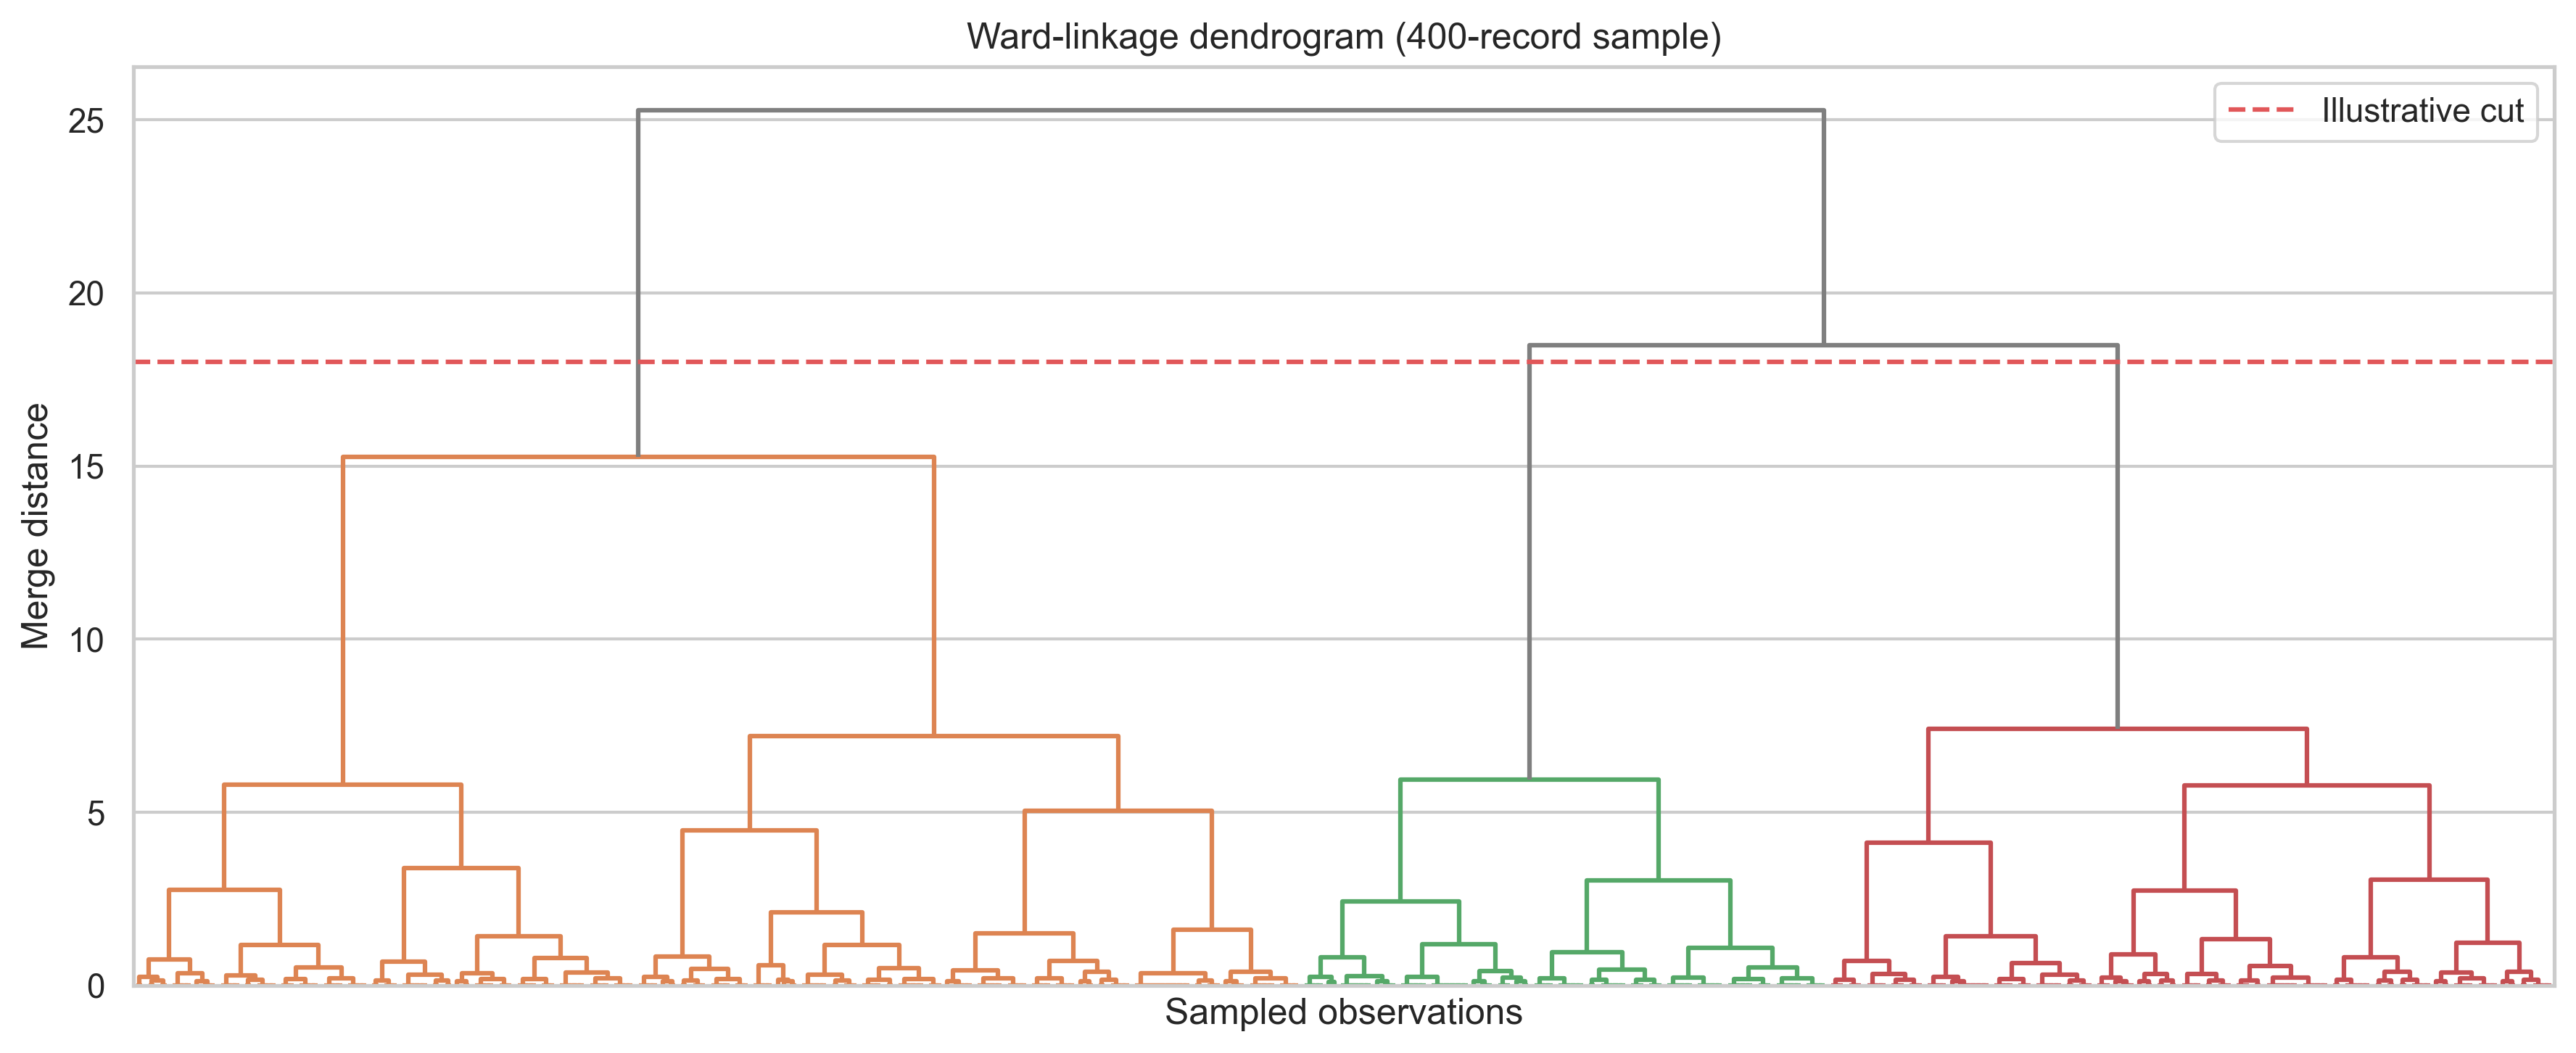

,linkage,clusters,silhouette,smallest_cluster,largest_cluster
2,average,4,0.427,1695,3268
3,ward,4,0.391,1919,3605
1,complete,4,0.380,1929,4008
0,single,4,0.263,2450,2587


In [6]:
# Build a Ward dendrogram on a reproducible 400-record sample.
dendrogram_index = df.sample(n=400, random_state=RANDOM_STATE).index
linkage_matrix = linkage(scaled_profile.loc[dendrogram_index], method='ward')

plt.figure(figsize=(12, 5))
dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=18,
    above_threshold_color='#7F7F7F',
)
plt.axhline(18, color='#E15759', linestyle='--', label='Illustrative cut')
plt.title('Ward-linkage dendrogram (400-record sample)')
plt.xlabel('Sampled observations')
plt.ylabel('Merge distance')
plt.legend()
plt.tight_layout()
plt.show()

# Compare all required linkage methods at the same four-cluster cut.
hac_rows = []
hac_labels = {}
for method in ['single', 'complete', 'average', 'ward']:
    labels = AgglomerativeClustering(n_clusters=4, linkage=method).fit_predict(X_profile)
    hac_labels[method] = labels
    sizes = pd.Series(labels).value_counts()
    hac_rows.append(
        {
            'linkage': method,
            'clusters': len(np.unique(labels)),
            'silhouette': silhouette_score(X_profile, labels),
            'smallest_cluster': sizes.min(),
            'largest_cluster': sizes.max(),
        }
    )

hac_comparison = pd.DataFrame(hac_rows).sort_values('silhouette', ascending=False)
display(hac_comparison.style.format({'silhouette': '{:.3f}'}))


### HAC result: linkage changes the answer

The dendrogram supports inspecting several possible cut heights rather than assuming a cluster count in advance. For a common four-cluster cut, the linkage comparison provides a validation-style sensitivity check: the silhouette values differ by linkage, with **average linkage (~0.427)** exceeding Ward (~0.391), complete (~0.380), and single (~0.263). Different linkage rules create different cluster sizes and boundaries from the same records. Reporting only one linkage method would overstate the stability of the result.


,campaigns,mean_subscription_length,mean_satisfaction,mean_revenue
HAC_Cluster,,,,
2,1919,28.88,1.43,"$50,418.03"
1,2543,9.48,1.47,"$49,957.54"
0,3605,23.91,3.32,"$49,561.20"
3,1933,7.46,3.40,"$50,659.06"


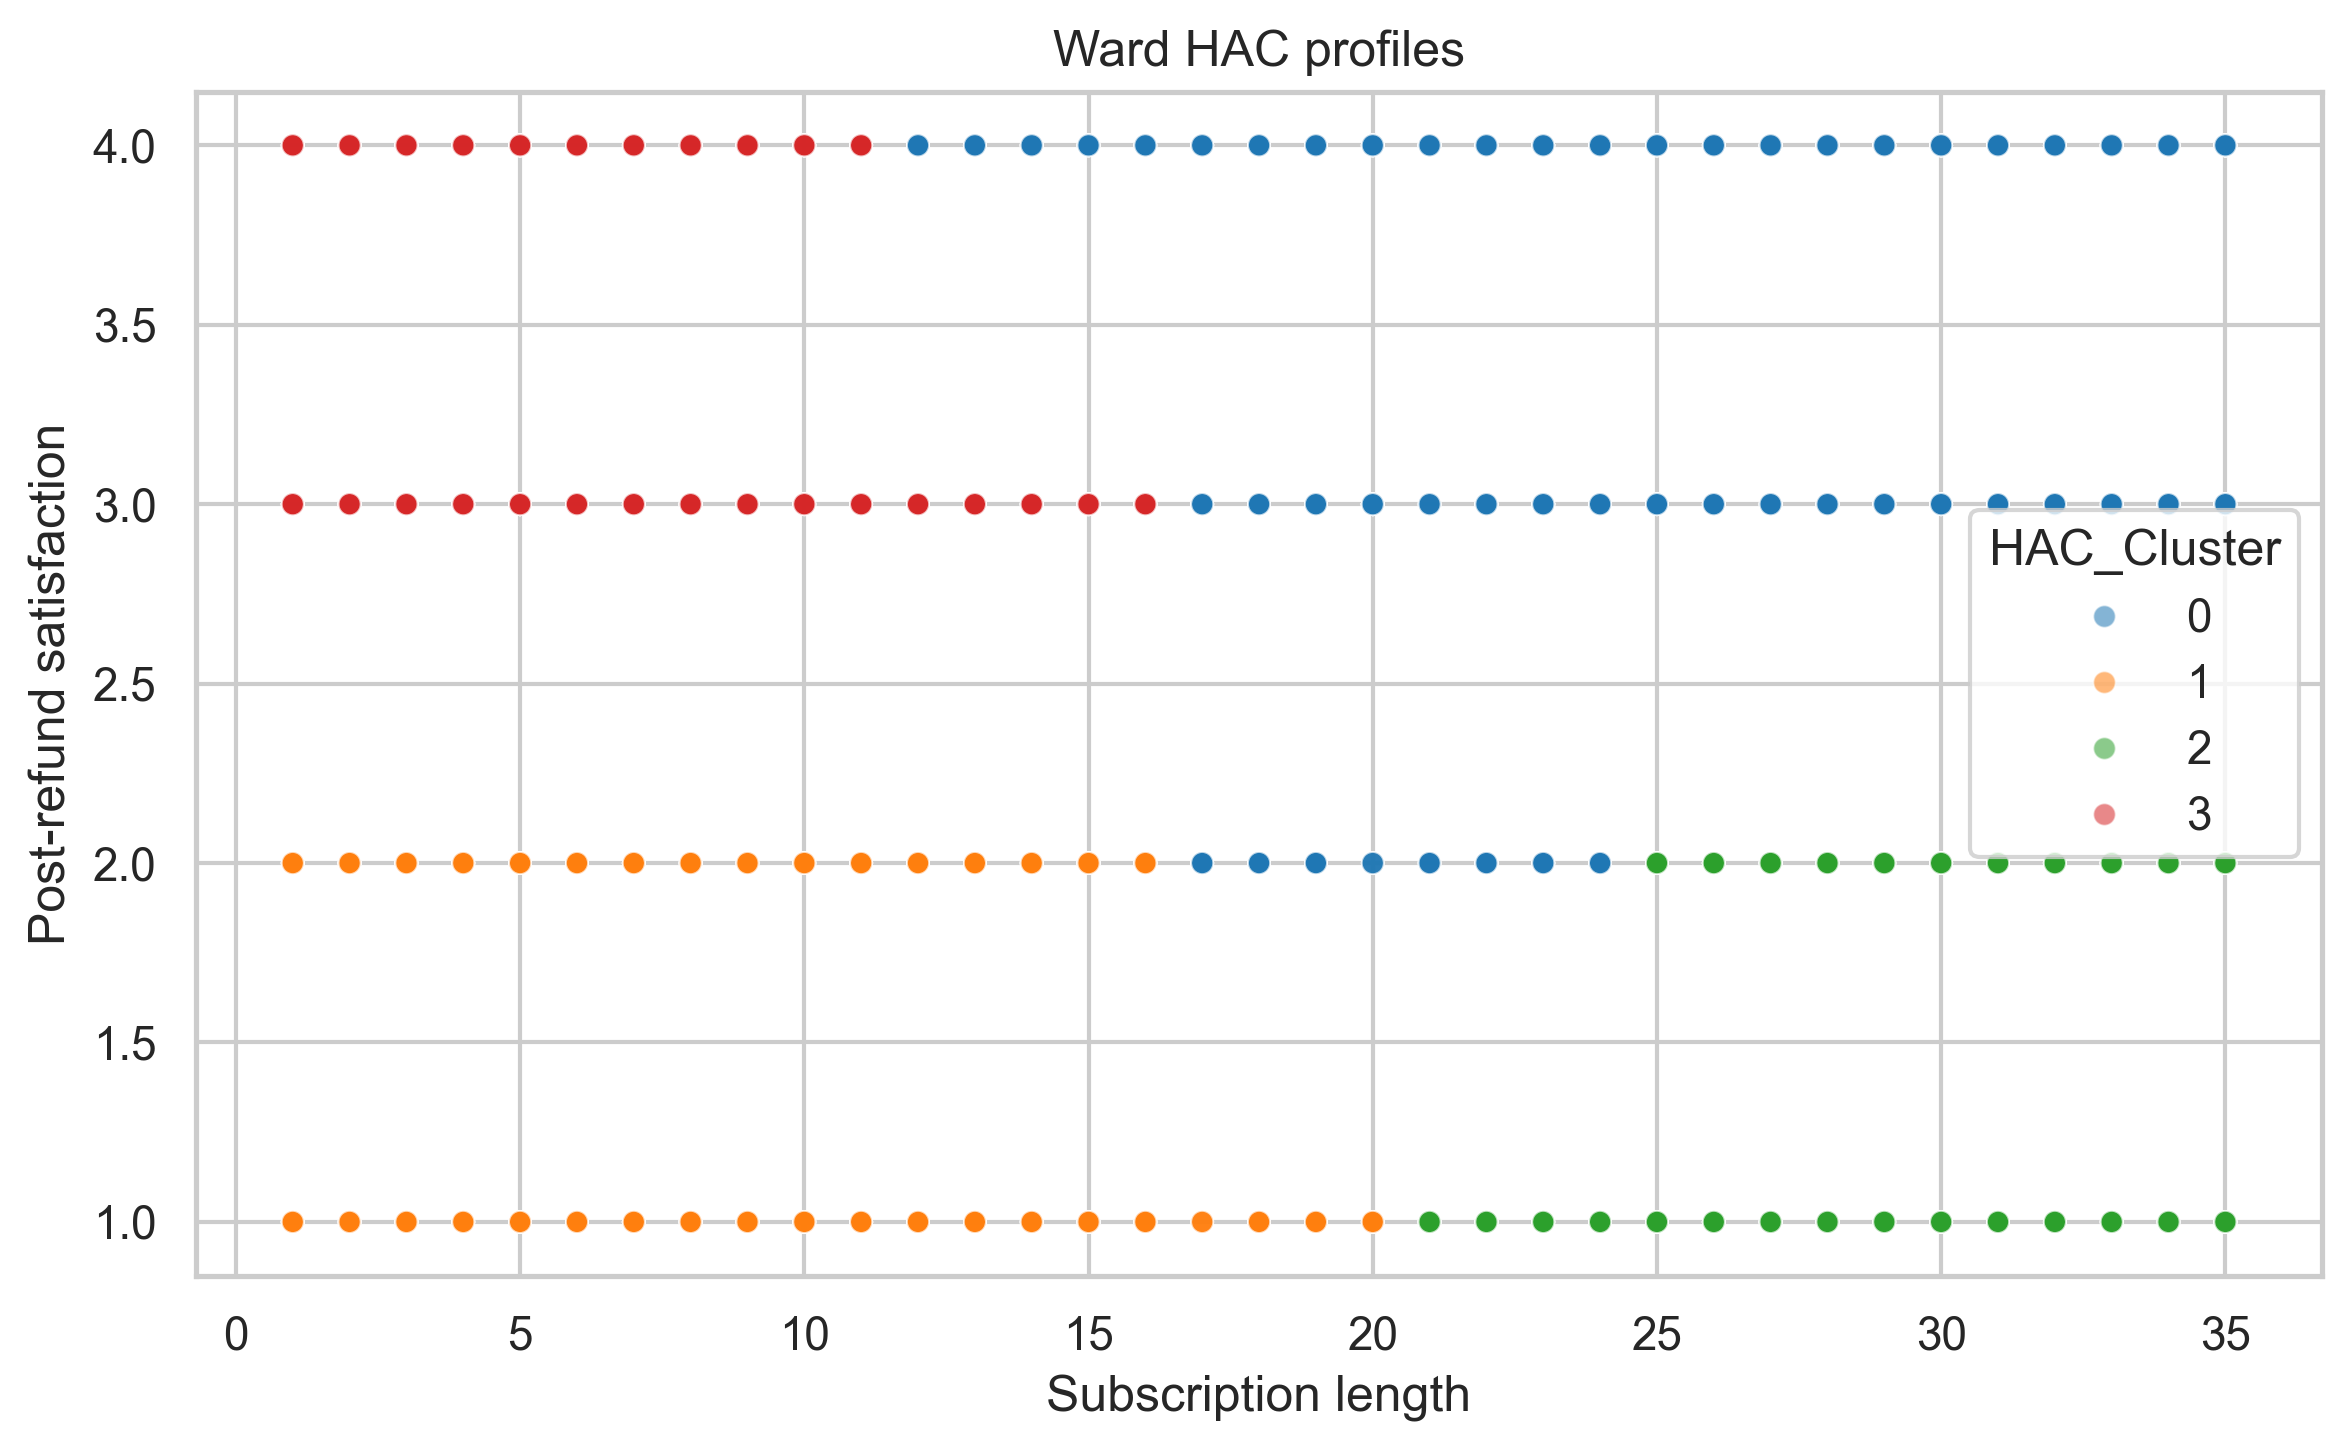

In [7]:
# Profile Ward clusters; revenue was excluded from fitting.
hac_results = df[profile_features + ['Revenue_Generated']].copy()
hac_results['HAC_Cluster'] = hac_labels['ward']

hac_profile = (
    hac_results.groupby('HAC_Cluster')
    .agg(
        campaigns=('Revenue_Generated', 'size'),
        mean_subscription_length=('Subscription_Length', 'mean'),
        mean_satisfaction=('Customer_Satisfaction_Post_Refund', 'mean'),
        mean_revenue=('Revenue_Generated', 'mean'),
    )
    .sort_values('mean_satisfaction')
)
display(
    hac_profile.style.format(
        {
            'mean_subscription_length': '{:.2f}',
            'mean_satisfaction': '{:.2f}',
            'mean_revenue': '${:,.2f}',
        }
    )
)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=hac_results.sample(n=2_000, random_state=RANDOM_STATE),
    x='Subscription_Length', y='Customer_Satisfaction_Post_Refund',
    hue='HAC_Cluster', palette='tab10', alpha=0.55, s=28,
)
plt.title('Ward HAC profiles')
plt.xlabel('Subscription length')
plt.ylabel('Post-refund satisfaction')
plt.tight_layout()
plt.show()


### Profile interpretation and business relevance

The Ward profiles summarize cluster size, average engagement characteristics, and mean revenue. Because revenue was excluded from fitting, these revenue means are a post-clustering description rather than a target the algorithm optimized. The profile table should be used to label broad engagement patterns, not to recommend revenue interventions. Any future marketing use would require external validation with real customer behavior and additional outcome data.


## Findings and reflection

**DBSCAN.** Epsilon controls neighborhood radius: too small fragments profiles and increases noise; too large merges regions. Increasing MinPts makes core status harder to achieve. The sensitivity table should therefore be considered alongside the selected setting.

**HAC.** The linkage comparison shows that the same requested cluster count can yield different compactness and cluster sizes. Single linkage can chain records; complete, average, and Ward use distinct merging criteria.

**Limitations and method choice.** Visible separation is substantially driven by the discrete satisfaction scale and intentionally narrow feature space. Results support exploratory engagement profiles, not validated natural segments. DBSCAN is useful for irregular dense regions and explicit noise detection; HAC is useful for nested structure, linkage sensitivity, and a dendrogram-based cut. Neither method supports causal or predictive claims here.


## Milestone Two evidence and safeguards

This notebook is self-contained for the Week 11 portion of Milestone Two: it states the research question, explains feature selection, documents EDA, applies DBSCAN and HAC, compares all required linkage methods, interprets a dendrogram, includes five labeled figures, and cites course/external sources.

**Safeguards:** identifiers and revenue are excluded from fitting; numeric inputs are standardized; sampling is reproducible; DBSCAN parameters are evaluated across a grid; silhouettes are reported with the noise label excluded; HAC linkage is compared at a common cluster count; and conclusions explicitly distinguish exploratory patterns from validated segments. These safeguards reduce overinterpretation but cannot remove the limitations of synthetic, low-cardinality inputs.


## Rubric evidence for this week: DBSCAN and HAC

**Project relevance and potential impact.** This analysis tests whether customer-engagement attributes support density-based or hierarchical profiles. Stable profiles could guide engagement research; identifying that the visible structure is largely an artifact of a discrete rating scale prevents invalid customer-segmentation claims.

**EDA role.** The audit established complete data, removed one-of-a-kind IDs, and revealed that satisfaction has only four levels. The initial scatterplot therefore gave an essential warning: horizontal bands may reflect the measurement scale rather than naturally occurring customer groups.

**Metrics and tuning.** DBSCAN sensitivity compares epsilon and MinPts using cluster count, noise share, and silhouette excluding noise. Epsilon is neighborhood radius; MinPts sets the core-density threshold. HAC compares single, complete, average, and Ward linkage at a common four-cluster cut using silhouette and cluster-size balance; the dendrogram makes hierarchical merge distances visible.

**Unsupported-segmentation safeguards and result.** IDs and revenue were excluded from fitting, variables were standardized, a k-nearest-neighbor distance diagnostic informed epsilon, multiple DBSCAN settings and HAC linkages were compared, and the dendrogram used a reproducible sample for readability. DBSCAN at the selected setting returned four all-core groups with no noise; linkage results changed by method. These checks show that apparent structure is sensitive to the low-cardinality feature representation.

**Expected and unexpected finding.** It was expected that DBSCAN parameters and HAC linkage would affect cluster geometry. It was unexpected that DBSCAN found no border or noise points and effectively reproduced the four satisfaction levels. The supported conclusion is exploratory engagement profiling only—not validated natural segments or a revenue-prediction result.

**AI-use documentation.** Generative AI (OpenAI Codex/ChatGPT) was used to assist with code formatting and explanatory prose. The student reviewed the data, modeling choices, executed outputs, conclusions, and citations, and remains responsible for the submission.


## Sources

Boston University. (2026). *Week 11 Overview; 11.1 Lesson: DBSCAN, Types of Points, and Clusters; 11.2 Lesson: HAC, Linkage Methods, and Dendrograms.*

Scikit-learn developers. (n.d.). *Clustering documentation*. https://scikit-learn.org/stable/modules/clustering.html

Shah, I. (n.d.). *Marketing and Product Performance Dataset* [Data set]. Kaggle. https://www.kaggle.com/datasets/imranalishahh/marketing-and-product-performance-dataset
